In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Load ----------
path = Path(r"H:/My Drive/career/proj/sprg/results/all_submissions_pepQuant.csv")
df = pd.read_csv(path)

# ---------- Basic column hygiene ----------
df.columns = [c.strip() for c in df.columns]

file_col = "File"
peptide_col = "Peptide"

# ---------- Sanity checks ----------
if file_col not in df.columns:
    raise ValueError(f"Missing required column: {file_col}")
if peptide_col not in df.columns:
    raise ValueError(f"Missing required column: {peptide_col}")

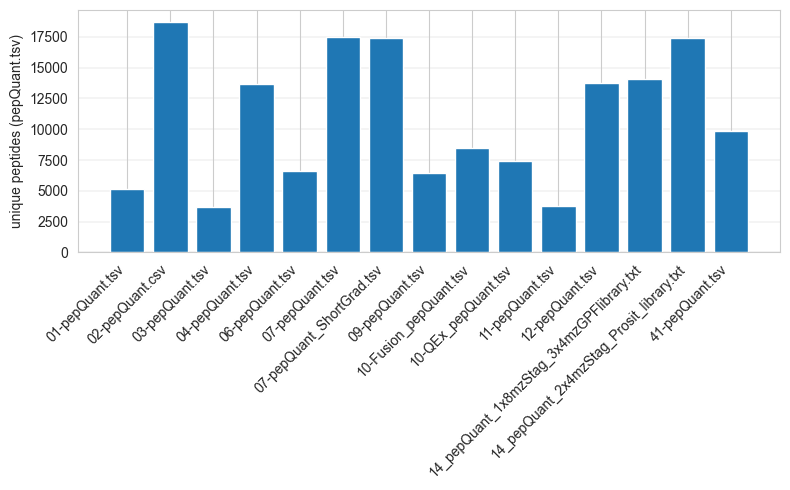

In [21]:
# ---------- Count unique peptides per participant ----------
counts = (
    df
    .groupby(file_col)[peptide_col]
    .nunique()
    .rename("n_peptides")
    .reset_index()
)

# ---------- Drop submissions with <= 1 peptide ----------
counts = counts[counts["n_peptides"] > 1]

# ---------- Shorten long site names for plotting ----------
counts["site_label"] = (
    counts[file_col]
    .astype(str)
    .str.replace("_sPRG_lumos_DIA", "", regex=False)
)

# ---------- Order by leading participant number ----------
# Extract leading integer (e.g. "02", "10") from the filename
counts["participant_num"] = (
    counts[file_col]
    .astype(str)
    .str.extract(r"^(\d+)")
    .astype(int)
)

# Sort by participant number
counts = counts.sort_values("participant_num")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(counts["site_label"], counts["n_peptides"])

ax.set_ylabel("unique peptides (pepQuant.tsv)")

ax.grid(True, axis="y", linewidth=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()



# concatenate all reported species percentages and make a box and whisker plot

In [56]:
project_dir = 'D:/2022 Multi-Species Standard Study'

import pandas as pd

def read_table_robust(fp: str) -> pd.DataFrame:
    # Try strict tab first
    try:
        return pd.read_csv(fp, sep="\t", engine="c")
    except Exception:
        pass

    # Try python engine (handles weird quoting better)
    try:
        return pd.read_csv(fp, sep="\t", engine="python")
    except Exception:
        pass

    # Try whitespace split (some people save as space-separated)
    try:
        return pd.read_csv(fp, sep=r"\s+", engine="python")
    except Exception:
        pass

    # Last resort: skip bad lines but keep what we can parse
    return pd.read_csv(fp, sep="\t", engine="python", on_bad_lines="skip")


In [57]:
import os
import re
import pandas as pd

all_df = []
bad_files = []

for subdir, dirs, files in os.walk(project_dir):
    for file in files:
        fname = file.lower()
        if "sampleratios" not in fname:
            continue

        fp = os.path.join(subdir, file)
        #print(fp)

        try:
            if fname.endswith(".csv"):
                df = pd.read_csv(fp)
            elif fname.endswith((".tsv", ".txt")):
                df = read_table_robust(fp)
            elif fname.endswith((".xlsx", ".xls")):
                df = pd.read_excel(fp)
            else:
                continue
        except Exception as e:
            bad_files.append((fp, str(e)))
            continue

        df.columns = [str(c).strip() for c in df.columns]

        # submission: prefer parent dir if numeric, else filename prefix
        parent = os.path.basename(subdir)
        if parent.isdigit():
            submission = parent.zfill(2)
        else:
            m = re.match(r"^(\d{2})", file)
            submission = m.group(1) if m else ""

        # dataset: filename stem without leading "07-" / "07_"
        stem = os.path.splitext(file)[0]
        dataset = re.sub(r"^\d{2}[-_]*", "", stem).strip()

        df["Submission"] = submission
        df["Dataset"] = dataset
        df["SourceFile"] = file
        df["SourcePath"] = fp

        all_df.append(df)

all_df = pd.concat(all_df, ignore_index=True)

print("Total rows:", len(all_df))
print("Unique submissions:", sorted([s for s in all_df["Submission"].unique() if s]))

if bad_files:
    print("\nFiles that failed to parse:")
    for fp, err in bad_files:
        print(" -", fp, ":", err)

all_df.to_csv("H:/My Drive/career/proj/sprg/results/all_submissions_sampleRatios_20251229.csv", index=False)
all_df.head()

Total rows: 146
Unique submissions: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']


,Sample,A/B,B/C,A/C,Submission,Dataset,SourceFile,SourcePath,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,cow,0.44,0.49,0.22,01,sampleRatios,01-sampleRatios.tsv,D:/2022 Multi-Species Standard Study\01\01-sam...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,human,2.82,2.37,6.70,01,sampleRatios,01-sampleRatios.tsv,D:/2022 Multi-Species Standard Study\01\01-sam...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,trout,1.43,0.70,1.00,01,sampleRatios,01-sampleRatios.tsv,D:/2022 Multi-Species Standard Study\01\01-sam...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cow,0.5,2.22,1.11,02,sampleRatios,02-sampleRatios.tsv,D:/2022 Multi-Species Standard Study\02\02-sam...,*this is fake data,NaN,NaN,NaN,NaN,NaN,NaN
4,human,NaN,NaN,NaN,02,sampleRatios,02-sampleRatios.tsv,D:/2022 Multi-Species Standard Study\02\02-sam...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
import pandas as pd
import numpy as np

df = all_df.copy()

keep_cols = ["Sample", "A/B", "B/C", "A/C", "Submission", "Dataset", "SourceFile"]
df = df[[c for c in keep_cols if c in df.columns]].copy()

# normalize species labels
df["species_norm"] = (
    df["Sample"].astype(str).str.strip().str.lower()
    .replace({
        "cow": "Bovin",
        "bovin": "Bovin",
        "bovine": "Bovin",
        "human": "Human",
        "trout": "Trout",
    })
)

# wide -> long
long_df = df.melt(
    id_vars=["species_norm", "Submission", "Dataset", "SourceFile"],
    value_vars=["A/B", "B/C", "A/C"],
    var_name="comparison",
    value_name="reported_ratio",
)

# numeric coercion only
long_df["reported_ratio"] = pd.to_numeric(long_df["reported_ratio"], errors="coerce")

# drop NaNs for plotting
p = long_df.dropna(subset=["reported_ratio"]).copy()

print(p.head())


  species_norm Submission       Dataset            SourceFile comparison  \
0        Bovin         01  sampleRatios   01-sampleRatios.tsv        A/B   
1        Human         01  sampleRatios   01-sampleRatios.tsv        A/B   
2        Trout         01  sampleRatios   01-sampleRatios.tsv        A/B   
3        Bovin         02  sampleRatios   02-sampleRatios.tsv        A/B   
6        Bovin         02  sampleRatios  02-sampleRatios.xlsx        A/B   

   reported_ratio  
0        0.440000  
1        2.820000  
2        1.430000  
3        0.500000  
6        0.865975  


In [60]:
# expected LINEAR ratios from the mix design
expected_linear = {
    "A/B": {
        "Bovin": 5 / 30,
        "Human": 45 / 20,
        "Trout": 50 / 50,
    },
    "B/C": {
        "Bovin": 30 / 47,
        "Human": 20 / 3,
        "Trout": 50 / 50,
    },
    "A/C": {
        "Bovin": 5 / 47,
        "Human": 45 / 3,
        "Trout": 50 / 50,
    },
}


C:\Users\linds\AppData\Local\Temp\ipykernel_40084\1465501025.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\linds\AppData\Local\Temp\ipykernel_40084\1465501025.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\linds\AppData\Local\Temp\ipykernel_40084\1465501025.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


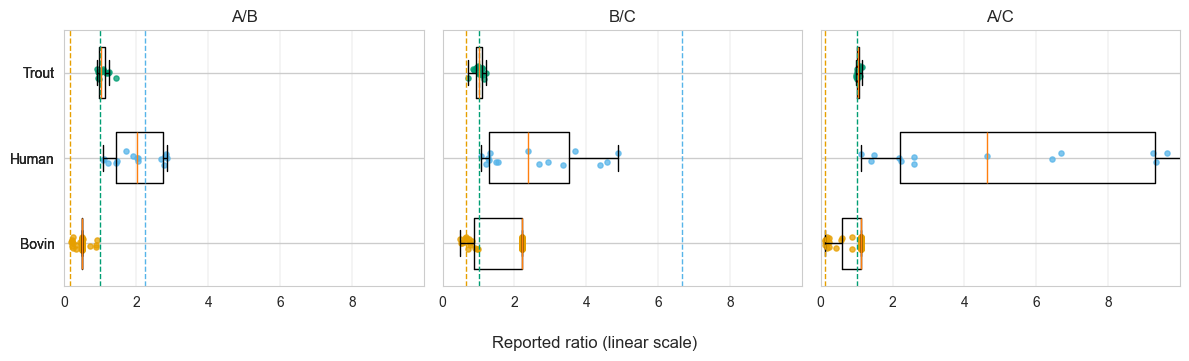

In [61]:
import matplotlib.pyplot as plt

species_order = ["Bovin", "Human", "Trout"]
colors = {"Bovin": "#E69F00", "Human": "#56B4E9", "Trout": "#009E73"}
comparisons = ["A/B", "B/C", "A/C"]

# shared x limits (linear, robust)
x_min, x_max = np.nanpercentile(p["reported_ratio"], [1, 99])
pad = 0.05 * (x_max - x_min)
x_lim = (max(0, x_min - pad), x_max + pad)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)

for ax, comp in zip(axes, comparisons):
    subc = p[p["comparison"] == comp]

    # boxplots
    data = [
        subc.loc[subc["species_norm"] == sp, "reported_ratio"].values
        for sp in species_order
    ]
    ax.boxplot(
        data,
        vert=False,
        labels=species_order,
        widths=0.6,
        showfliers=False,
    )

    # jittered points + expected lines
    for i, sp in enumerate(species_order, start=1):
        ss = subc[subc["species_norm"] == sp]
        if not ss.empty:
            y = np.full(len(ss), i) + np.random.uniform(-0.08, 0.08, size=len(ss))
            ax.scatter(
                ss["reported_ratio"],
                y,
                s=14,
                alpha=0.75,
                color=colors[sp],
            )

        # expected linear ratio
        ax.axvline(
            expected_linear[comp][sp],
            linestyle="--",
            linewidth=1,
            color=colors[sp],
        )

    ax.set_title(comp)
    ax.set_xlim(*x_lim)
    ax.grid(True, axis="x", linewidth=0.3)

fig.supxlabel("Reported ratio (linear scale)")
plt.tight_layout()
plt.show()


C:\Users\linds\AppData\Local\Temp\ipykernel_40084\921625017.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\linds\AppData\Local\Temp\ipykernel_40084\921625017.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\linds\AppData\Local\Temp\ipykernel_40084\921625017.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


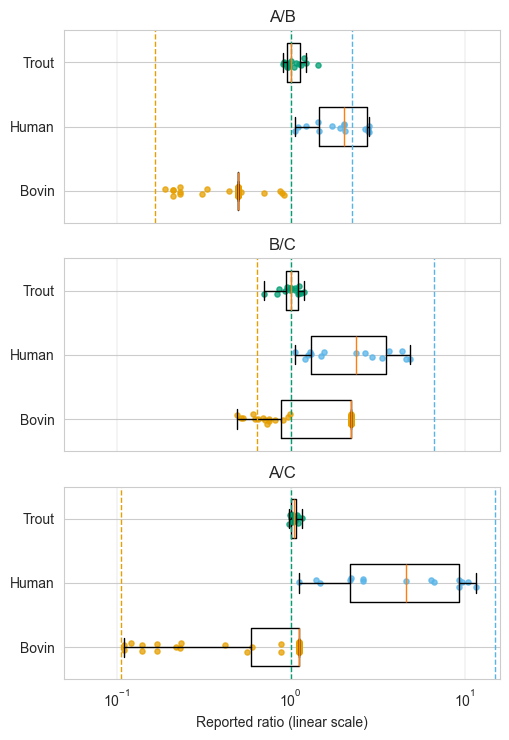

In [64]:
import matplotlib.pyplot as plt
import numpy as np

species_order = ["Bovin", "Human", "Trout"]
colors = {"Bovin": "#E69F00", "Human": "#56B4E9", "Trout": "#009E73"}
comparisons = ["A/B", "B/C", "A/C"]

# shared x limits (linear)
x_lim = (0.05, 16)  # lower bound must be > 0 for log scale

fig, axes = plt.subplots(3, 1, figsize=(5.2, 7.5), sharex=True)

for ax, comp in zip(axes, comparisons):
    subc = p[p["comparison"] == comp]

    # boxplots (horizontal)
    data = [
        subc.loc[subc["species_norm"] == sp, "reported_ratio"].values
        for sp in species_order
    ]
    ax.boxplot(
        data,
        vert=False,
        labels=species_order,
        widths=0.6,
        showfliers=False,
    )

    ax.set_xscale("log")

    # jittered points + expected lines
    for i, sp in enumerate(species_order, start=1):
        ss = subc[subc["species_norm"] == sp]
        if not ss.empty:
            y = np.full(len(ss), i) + np.random.uniform(-0.08, 0.08, size=len(ss))
            ax.scatter(
                ss["reported_ratio"],
                y,
                s=14,
                alpha=0.75,
                color=colors[sp],
            )

        # expected linear ratio
        ax.axvline(
            expected_linear[comp][sp],
            linestyle="--",
            linewidth=1,
            color=colors[sp],
        )

    ax.set_title(comp)
    ax.set_xlim(*x_lim)
    ax.grid(True, axis="x", linewidth=0.3)

axes[-1].set_xlabel("Reported ratio (linear scale)")

plt.tight_layout()
plt.show()
